In [1]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# setting project root
import os

PROJECT_ROOT = "/content"
REPO_URL = "https://github.com/sheldonsoudin/LLM_Inference_time_ablation_Iterative_analysis.git"
REPO_DIR = os.path.join(PROJECT_ROOT, "LLM_Inference_time_ablation_Iterative_analysis")


In [3]:
# cloning or pulling repo depending on if its in drive

%cd /content

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd $REPO_DIR
    !git pull

%cd $REPO_DIR
!pwd
!ls

/content
Cloning into 'LLM_Inference_time_ablation_Iterative_analysis'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 107 (delta 54), reused 22 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 949.03 KiB | 12.49 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/LLM_Inference_time_ablation_Iterative_analysis
/content/LLM_Inference_time_ablation_Iterative_analysis
data.py					 Project_Proposal_Form_new_version.pdf
main_project_40068843_serious_run.ipynb  README.md
model.py				 train.py


In [4]:
#clean up older version
#!rm -rf /content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints/run1

In [5]:
#dependencies

!pip install -q torch transformers datasets huggingface_hub

In [6]:
#checking GPU and imports

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from model import GPT, GPTConfig
from data import build_train_dataloader, estimate_num_steps
print("Imports OK")

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Imports OK


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## training run

this cell trains the ~350M scratch model.


In [8]:
# This cell must be uncommented to train the model, otherwise the trained l

# training run
#!python train.py \
 # --n_layer 24 \
  #--n_head 16 \
  #--n_embd 1024 \
  #--batch_size 4 \
  #--grad_accum_steps 8 \
  #--block_size 1024 \
  #--max_steps 25000 \
  #--target_tokens 819200000 \
  #--save_interval 1000 \
  #--num_workers 0 \
  #--output_dir /content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints/run1


In [9]:
# inspecting saved checkpoints

import os

ckpt_root = "/content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints/run1"
if os.path.exists(ckpt_root):
    for name in sorted(os.listdir(ckpt_root)):
        print(name)
else:
    print("No checkpoints yet.")

checkpoint_step_1000
checkpoint_step_10000
checkpoint_step_11000
checkpoint_step_12000
checkpoint_step_13000
checkpoint_step_14000
checkpoint_step_15000
checkpoint_step_16000
checkpoint_step_17000
checkpoint_step_18000
checkpoint_step_19000
checkpoint_step_2000
checkpoint_step_20000
checkpoint_step_21000
checkpoint_step_22000
checkpoint_step_23000
checkpoint_step_24000
checkpoint_step_3000
checkpoint_step_4000
checkpoint_step_5000
checkpoint_step_6000
checkpoint_step_7000
checkpoint_step_8000
checkpoint_step_9000
final_model


In [10]:
## adding changes back to repo

#!git status
#!git add .
#!git commit -m "Update training setup from Colab"
#!git push

In [26]:
# genration test


import json
import torch
from transformers import AutoTokenizer

from model import GPT, GPTConfig

#saved folder
CKPT_DIR = "/content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints/run1/final_model"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# load config
with open(f"{CKPT_DIR}/config.json", "r") as f:
    cfg_dict = json.load(f)

config = GPTConfig(**cfg_dict)

# build model and load weights
model = GPT(config)
state_dict = torch.load(f"{CKPT_DIR}/pytorch_model.bin", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# load tokenizer saved with the checkpoint
tokenizer = AutoTokenizer.from_pretrained(CKPT_DIR)

# PROMPT --------------
prompt = "I like comp432, which is the course I did this experiment but"
inputs = tokenizer(prompt, return_tensors="pt")
idx = inputs["input_ids"].to(device)

#next token prediction
with torch.no_grad():
    logits, _ = model(idx)
    next_token_logits = logits[:, -1, :]
    probs = torch.softmax(next_token_logits, dim=-1)

top_k = 10
top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)

print("Top next-token predictions:")
for rank, (tok_id, prob) in enumerate(zip(top_ids[0].tolist(), top_probs[0].tolist()), start=1):
    tok_text = tokenizer.decode([tok_id])
    print(f"{rank:2d}. token_id={tok_id:5d}  prob={prob:.4f}  token={repr(tok_text)}")

# multitoken prediction: option to see
generated = model.generate(
    idx,
    max_new=40,
    temperature=0.8,
    top_k=50,
)

print("\nGenerated text:\n")
print(tokenizer.decode(generated[0], skip_special_tokens=True))

Using device: cuda
 gpt initialisation done - 354,823,168 number of parameters354.8M)
Top next-token predictions:
 1. token_id=  314  prob=0.2131  token=' I'
 2. token_id=  340  prob=0.0815  token=' it'
 3. token_id=  262  prob=0.0415  token=' the'
 4. token_id=  373  prob=0.0346  token=' was'
 5. token_id=  407  prob=0.0287  token=' not'
 6. token_id=  318  prob=0.0283  token=' is'
 7. token_id=  351  prob=0.0263  token=' with'
 8. token_id= 1422  prob=0.0257  token=' didn'
 9. token_id=  468  prob=0.0149  token=' has'
10. token_id=  635  prob=0.0121  token=' also'

Generated text:

I like comp432, which is the course I did this experiment but in a different way.

The other thing I noticed was that the 3-D display of the field function was not the same as the one in the last experiment. The next step was to


In [12]:
#for rerun and to delete past runs.

#!ls /content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints

Pythia loading

In [13]:
!pip install -q transformers accelerate

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "EleutherAI/pythia-410m"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
)

if not torch.cuda.is_available():
    model = model.to(device)

print(type(model))
print("Loaded on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/911M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

<class 'transformers.models.gpt_neox.modeling_gpt_neox.GPTNeoXForCausalLM'>
Loaded on: cuda


In [14]:
prompt = "I like comp432, which is the course I did this experiment but "

inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=True,
        temperature=0.8,
        top_k=50,
    )

print(tokenizer.decode(out[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


I like comp432, which is the course I did this experiment but ive taken a few more hours this week than last week.

Ive been watching the videos and found this to be very interesting. If you


\Ablation and benchmark evaluation loop with visualizationas


ablation and benchmark loop



In [15]:
# Benchmark / model comparison settings
import os
import gc
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

SCRATCH_CKPT_DIR = "/content/drive/MyDrive/gpt_comp432_project_40068843/checkpoints/run1/final_model"
PYTHIA_MODEL_ID = "EleutherAI/pythia-410m"

RESULTS_DIR = "/content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

HELLASWAG_N = 100
MMLU_SUBJECTS = [
    "high_school_biology",
    "high_school_mathematics",
    "computer_security",
]
MMLU_N_PER_SUBJECT = 10
RANDOM_SEED = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVAL_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

print("DEVICE:", DEVICE)
print("EVAL_DTYPE:", EVAL_DTYPE)
print("RESULTS_DIR:", RESULTS_DIR)


DEVICE: cuda
EVAL_DTYPE: torch.float16
RESULTS_DIR: /content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results


In [16]:
# Shared helpers
LETTERS = ["A", "B", "C", "D"]

def get_model_device(model):
    return next(model.parameters()).device


def get_model_max_positions(model):
    cfg = getattr(model, "config", None)
    if cfg is not None:
        for attr in ["n_ctx", "max_position_embeddings", "n_positions"]:
            if hasattr(cfg, attr):
                return int(getattr(cfg, attr))
    return 1024


def get_model_logits(model, input_ids):
    outputs = model(input_ids)
    if isinstance(outputs, tuple):
        return outputs[0]
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, dict) and "logits" in outputs:
        return outputs["logits"]
    raise TypeError(f"Unsupported model output type: {type(outputs)}")


def smart_join(ctx, cont):
    ctx = ctx.rstrip()
    cont = cont.lstrip()
    if not ctx:
        return cont
    if cont and cont[0] in ",.!?;:":
        return ctx + cont
    return ctx + " " + cont


@torch.no_grad()
def continuation_score(model, tokenizer, prompt, continuation, normalize_by_length=True):
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    cont_ids = tokenizer(continuation, add_special_tokens=False)["input_ids"]

    if len(cont_ids) == 0:
        return float("-inf")

    max_pos = get_model_max_positions(model)
    total_len = len(prompt_ids) + len(cont_ids)
    if total_len > max_pos:
        overflow = total_len - max_pos
        prompt_ids = prompt_ids[overflow:]

    device = get_model_device(model)
    input_ids = torch.tensor([prompt_ids + cont_ids], dtype=torch.long, device=device)
    logits = get_model_logits(model, input_ids)

    shift_logits = logits[:, :-1, :]
    shift_targets = input_ids[:, 1:]

    cont_start = max(0, len(prompt_ids) - 1)
    cont_logits = shift_logits[:, cont_start:, :]
    cont_targets = shift_targets[:, cont_start:]

    if cont_targets.numel() == 0:
        return float("-inf")

    log_probs = torch.log_softmax(cont_logits, dim=-1)
    token_log_probs = log_probs.gather(-1, cont_targets.unsqueeze(-1)).squeeze(-1)

    if normalize_by_length:
        return token_log_probs.mean().item()
    return token_log_probs.sum().item()


def format_mmlu_prompt(ex):
    lines = [f"Question: {ex['question']}"]
    for letter, choice in zip(LETTERS, ex["choices"]):
        lines.append(f"{letter}. {choice}")
    lines.append("Answer:")
    return "".join(lines)


def mmlu_answer_to_index(ans):
    if isinstance(ans, int):
        return ans
    if isinstance(ans, str):
        ans = ans.strip()
        if ans in LETTERS:
            return LETTERS.index(ans)
        if ans.isdigit():
            return int(ans)
    raise ValueError(f"Unrecognized MMLU answer format: {ans!r}")


In [17]:
# Loaders for scratch model and for Pythia 410M
from model import GPT, GPTConfig


def load_scratch_model(ckpt_dir, device=DEVICE):
    tokenizer = AutoTokenizer.from_pretrained(ckpt_dir)
    with open(os.path.join(ckpt_dir, "config.json"), "r") as f:
        cfg_dict = json.load(f)
    config = GPTConfig(**cfg_dict)
    model = GPT(config)
    state_dict = torch.load(os.path.join(ckpt_dir, "pytorch_model.bin"), map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model, tokenizer


def load_pythia_model(model_id=PYTHIA_MODEL_ID, device=DEVICE, dtype=EVAL_DTYPE):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype)
    model.to(device)
    model.eval()
    return model, tokenizer


In [18]:
# Benchmark evaluators (for by both models)
@torch.no_grad()
def eval_hellaswag(model, tokenizer, n_examples=100, seed=42):
    ds = load_dataset("Rowan/hellaswag", split="validation")
    ds = ds.shuffle(seed=seed).select(range(min(n_examples, len(ds))))

    correct = 0
    rows = []

    for ex in tqdm(ds, desc=f"HellaSwag ({n_examples})"):
        prompt = ex["ctx"]
        choices = ex["endings"]
        gold = int(ex["label"])

        scores = [
            continuation_score(
                model,
                tokenizer,
                prompt,
                smart_join("", choice),
                normalize_by_length=True,
            )
            for choice in choices
        ]
        pred = int(np.argmax(scores))
        correct += int(pred == gold)

        rows.append({
            "benchmark": "hellaswag",
            "correct": int(pred == gold),
            "pred": pred,
            "gold": gold,
        })

    acc = correct / len(ds)
    return {
        "benchmark": "hellaswag",
        "accuracy": acc,
        "n": len(ds),
        "details": pd.DataFrame(rows),
    }


@torch.no_grad()
def eval_mmlu(model, tokenizer, subjects, n_per_subject=10, seed=42):
    rows = []
    total = 0
    correct = 0

    for subject in subjects:
        ds = load_dataset("cais/mmlu", subject, split="test")
        ds = ds.shuffle(seed=seed).select(range(min(n_per_subject, len(ds))))

        for ex in tqdm(ds, desc=f"MMLU/{subject} ({n_per_subject})", leave=False):
            prompt = format_mmlu_prompt(ex)
            scores = [
                continuation_score(
                    model,
                    tokenizer,
                    prompt,
                    f" {letter}",
                    normalize_by_length=False,
                )
                for letter in LETTERS
            ]
            pred = int(np.argmax(scores))
            gold = mmlu_answer_to_index(ex["answer"])

            total += 1
            correct += int(pred == gold)

            rows.append({
                "benchmark": "mmlu",
                "subject": subject,
                "correct": int(pred == gold),
                "pred": pred,
                "gold": gold,
            })

    return {
        "benchmark": "mmlu",
        "accuracy": correct / total if total else 0.0,
        "n": total,
        "details": pd.DataFrame(rows),
    }


def run_benchmarks(model, tokenizer, hellaswag_n=100, mmlu_subjects=None, mmlu_n_per_subject=10):
    if mmlu_subjects is None:
        mmlu_subjects = MMLU_SUBJECTS

    hs = eval_hellaswag(model, tokenizer, n_examples=hellaswag_n, seed=RANDOM_SEED)
    mm = eval_mmlu(model, tokenizer, subjects=mmlu_subjects, n_per_subject=mmlu_n_per_subject, seed=RANDOM_SEED)

    summary = pd.DataFrame([
        {"benchmark": hs["benchmark"], "accuracy": hs["accuracy"], "n": hs["n"]},
        {"benchmark": mm["benchmark"], "accuracy": mm["accuracy"], "n": mm["n"]},
    ])

    return {
        "summary": summary,
        "hellaswag_details": hs["details"],
        "mmlu_details": mm["details"],
    }


In [19]:
# Ablation helpers and model-specific ablation plans

def get_module_dict(model):
    return dict(model.named_modules())


def ablate_modules_zero_(model, module_names):
    modules = get_module_dict(model)
    backups = []
    with torch.no_grad():
        for name in module_names:
            if name not in modules:
                raise KeyError(f"Module not found: {name}")
            module = modules[name]
            params = list(module.parameters())
            local_backup = [(p, p.detach().clone()) for p in params]
            for p in params:
                p.zero_()
            backups.append((name, local_backup))
    return backups


def restore_modules_(backups):
    with torch.no_grad():
        for _, local_backup in backups:
            for p, saved in local_backup:
                p.copy_(saved)


def build_scratch_ablation_plan(model):
    n_layers = model.config.n_layer
    positions = [
        ("early", 0),
        ("middle", n_layers // 2),
        ("late", n_layers - 1),
    ]
    plan = [{"ablation": "baseline", "targets": []}]
    for label, i in positions:
        plan.extend([
            {"ablation": f"{label}_attn_qkv",  "targets": [f"transformer.h.{i}.attn.qkv"]},
            {"ablation": f"{label}_attn_out",  "targets": [f"transformer.h.{i}.attn.proj"]},
            {"ablation": f"{label}_mlp_up",    "targets": [f"transformer.h.{i}.mlp.fc"]},
            {"ablation": f"{label}_mlp_down",  "targets": [f"transformer.h.{i}.mlp.proj"]},
        ])
    return plan


def build_pythia_ablation_plan(model):
    n_layers = len(model.gpt_neox.layers)
    positions = [
        ("early", 0),
        ("middle", n_layers // 2),
        ("late", n_layers - 1),
    ]
    plan = [{"ablation": "baseline", "targets": []}]
    for label, i in positions:
        plan.extend([
            {"ablation": f"{label}_attn_qkv",  "targets": [f"gpt_neox.layers.{i}.attention.query_key_value"]},
            {"ablation": f"{label}_attn_out",  "targets": [f"gpt_neox.layers.{i}.attention.dense"]},
            {"ablation": f"{label}_mlp_up",    "targets": [f"gpt_neox.layers.{i}.mlp.dense_h_to_4h"]},
            {"ablation": f"{label}_mlp_down",  "targets": [f"gpt_neox.layers.{i}.mlp.dense_4h_to_h"]},
        ])
    return plan


def run_ablation_suite(model_name, model, tokenizer, ablation_plan, hellaswag_n=100, mmlu_subjects=None, mmlu_n_per_subject=10):
    all_rows = []
    detail_store = {}

    for ab in ablation_plan:
        print(f"\n=== {model_name}: {ab['ablation']} ===")
        backups = None
        if ab["targets"]:
            backups = ablate_modules_zero_(model, ab["targets"])

        try:
            out = run_benchmarks(
                model,
                tokenizer,
                hellaswag_n=hellaswag_n,
                mmlu_subjects=mmlu_subjects,
                mmlu_n_per_subject=mmlu_n_per_subject,
            )
        finally:
            if backups is not None:
                restore_modules_(backups)

        summary = out["summary"].copy()
        summary["model_family"] = model_name
        summary["ablation"] = ab["ablation"]
        summary["targets"] = [", ".join(ab["targets"])] * len(summary)
        all_rows.append(summary)

        detail_store[ab["ablation"]] = {
            "hellaswag": out["hellaswag_details"],
            "mmlu": out["mmlu_details"],
        }

    results = pd.concat(all_rows, ignore_index=True)
    baseline = (
        results[results["ablation"] == "baseline"]
        .set_index("benchmark")["accuracy"]
        .to_dict()
    )
    results["delta_vs_model_baseline"] = results.apply(
        lambda r: r["accuracy"] - baseline[r["benchmark"]],
        axis=1,
    )
    return results, detail_store


def cleanup_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [20]:
#run the scratch-model suite
scratch_model, scratch_tokenizer = load_scratch_model(SCRATCH_CKPT_DIR)
scratch_plan = build_scratch_ablation_plan(scratch_model)

scratch_results, scratch_details = run_ablation_suite(
    model_name="scratch_gpt",
    model=scratch_model,
    tokenizer=scratch_tokenizer,
    ablation_plan=scratch_plan,
    hellaswag_n=HELLASWAG_N,
    mmlu_subjects=MMLU_SUBJECTS,
    mmlu_n_per_subject=MMLU_N_PER_SUBJECT,
)

scratch_results.to_csv(os.path.join(RESULTS_DIR, "scratch_ablation_results.csv"), index=False)
display(scratch_results)

cleanup_model(scratch_model)
del scratch_tokenizer


 gpt initialisation done - 354,823,168 number of parameters354.8M)

=== scratch_gpt: baseline ===


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/24.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.32M [00:00<?, ?B/s]

...

HellaSwag (100):   0%|          | 0/100 [00:00<?, ?it/s]

MMLU/high_school_biology (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/high_school_mathematics (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/computer_security (10):   0%|          | 0/10 [00:00<?, ?it/s]

,benchmark,accuracy,n,model_family,ablation,targets,delta_vs_model_baseline
0,hellaswag,0.240000,100,scratch_gpt,baseline,,0.000000
1,mmlu,0.166667,30,scratch_gpt,baseline,,0.000000
2,hellaswag,0.240000,100,scratch_gpt,early_attn_qkv,transformer.h.0.attn.qkv,0.000000
3,mmlu,0.166667,30,scratch_gpt,early_attn_qkv,transformer.h.0.attn.qkv,0.000000
4,hellaswag,0.240000,100,scratch_gpt,early_attn_out,transformer.h.0.attn.proj,0.000000
5,mmlu,0.166667,30,scratch_gpt,early_attn_out,transformer.h.0.attn.proj,0.000000
6,hellaswag,0.290000,100,scratch_gpt,early_mlp_up,transformer.h.0.mlp.fc,0.050000
7,mmlu,0.133333,30,scratch_gpt,early_mlp_up,transformer.h.0.mlp.fc,-0.033333
8,hellaswag,0.300000,100,scratch_gpt,early_mlp_down,transformer.h.0.mlp.proj,0.060000
9,mmlu,0.200000,30,scratch_gpt,early_mlp_down,transformer.h.0.mlp.proj,0.033333


In [21]:
# Run the Pythia 410M suite
pythia_model, pythia_tokenizer = load_pythia_model(PYTHIA_MODEL_ID)
pythia_plan = build_pythia_ablation_plan(pythia_model)

pythia_results, pythia_details = run_ablation_suite(
    model_name="pythia_410m",
    model=pythia_model,
    tokenizer=pythia_tokenizer,
    ablation_plan=pythia_plan,
    hellaswag_n=HELLASWAG_N,
    mmlu_subjects=MMLU_SUBJECTS,
    mmlu_n_per_subject=MMLU_N_PER_SUBJECT,
)

pythia_results.to_csv(os.path.join(RESULTS_DIR, "pythia_ablation_results.csv"), index=False)
display(pythia_results)

cleanup_model(pythia_model)
del pythia_tokenizer


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


=== pythia_410m: baseline ===


HellaSwag (100):   0%|          | 0/100 [00:00<?, ?it/s]

MMLU/high_school_biology (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/high_school_mathematics (10):   0%|          | 0/10 [00:00<?, ?it/s]

...

HellaSwag (100):   0%|          | 0/100 [00:00<?, ?it/s]

MMLU/high_school_biology (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/high_school_mathematics (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/computer_security (10):   0%|          | 0/10 [00:00<?, ?it/s]

,benchmark,accuracy,n,model_family,ablation,targets,delta_vs_model_baseline
0,hellaswag,0.360000,100,pythia_410m,baseline,,0.000000
1,mmlu,0.166667,30,pythia_410m,baseline,,0.000000
2,hellaswag,0.350000,100,pythia_410m,early_attn_qkv,gpt_neox.layers.0.attention.query_key_value,-0.010000
3,mmlu,0.133333,30,pythia_410m,early_attn_qkv,gpt_neox.layers.0.attention.query_key_value,-0.033333
4,hellaswag,0.310000,100,pythia_410m,early_attn_out,gpt_neox.layers.0.attention.dense,-0.050000
5,mmlu,0.133333,30,pythia_410m,early_attn_out,gpt_neox.layers.0.attention.dense,-0.033333
6,hellaswag,0.230000,100,pythia_410m,early_mlp_up,gpt_neox.layers.0.mlp.dense_h_to_4h,-0.130000
7,mmlu,0.166667,30,pythia_410m,early_mlp_up,gpt_neox.layers.0.mlp.dense_h_to_4h,0.000000
8,hellaswag,0.260000,100,pythia_410m,early_mlp_down,gpt_neox.layers.0.mlp.dense_4h_to_h,-0.100000
9,mmlu,0.166667,30,pythia_410m,early_mlp_down,gpt_neox.layers.0.mlp.dense_4h_to_h,0.000000


In [22]:
# Combine, side-by-side results
combined_results = pd.concat([scratch_results, pythia_results], ignore_index=True)
combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_ablation_results.csv"), index=False)

print("Saved:")
print(os.path.join(RESULTS_DIR, "scratch_ablation_results.csv"))
print(os.path.join(RESULTS_DIR, "pythia_ablation_results.csv"))
print(os.path.join(RESULTS_DIR, "combined_ablation_results.csv"))

display(combined_results.sort_values(["benchmark", "model_family", "ablation"]))


Saved:
/content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results/scratch_ablation_results.csv
/content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results/pythia_ablation_results.csv
/content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results/combined_ablation_results.csv


,benchmark,accuracy,n,model_family,ablation,targets,delta_vs_model_baseline
26,hellaswag,0.360000,100,pythia_410m,baseline,,0.000000
30,hellaswag,0.310000,100,pythia_410m,early_attn_out,gpt_neox.layers.0.attention.dense,-0.050000
28,hellaswag,0.350000,100,pythia_410m,early_attn_qkv,gpt_neox.layers.0.attention.query_key_value,-0.010000
34,hellaswag,0.260000,100,pythia_410m,early_mlp_down,gpt_neox.layers.0.mlp.dense_4h_to_h,-0.100000
32,hellaswag,0.230000,100,pythia_410m,early_mlp_up,gpt_neox.layers.0.mlp.dense_h_to_4h,-0.130000
46,hellaswag,0.360000,100,pythia_410m,late_attn_out,gpt_neox.layers.23.attention.dense,0.000000
44,hellaswag,0.350000,100,pythia_410m,late_attn_qkv,gpt_neox.layers.23.attention.query_key_value,-0.010000
50,hellaswag,0.310000,100,pythia_410m,late_mlp_down,gpt_neox.layers.23.mlp.dense_4h_to_h,-0.050000
48,hellaswag,0.300000,100,pythia_410m,late_mlp_up,gpt_neox.layers.23.mlp.dense_h_to_4h,-0.060000
38,hellaswag,0.350000,100,pythia_410m,middle_attn_out,gpt_neox.layers.12.attention.dense,-0.010000


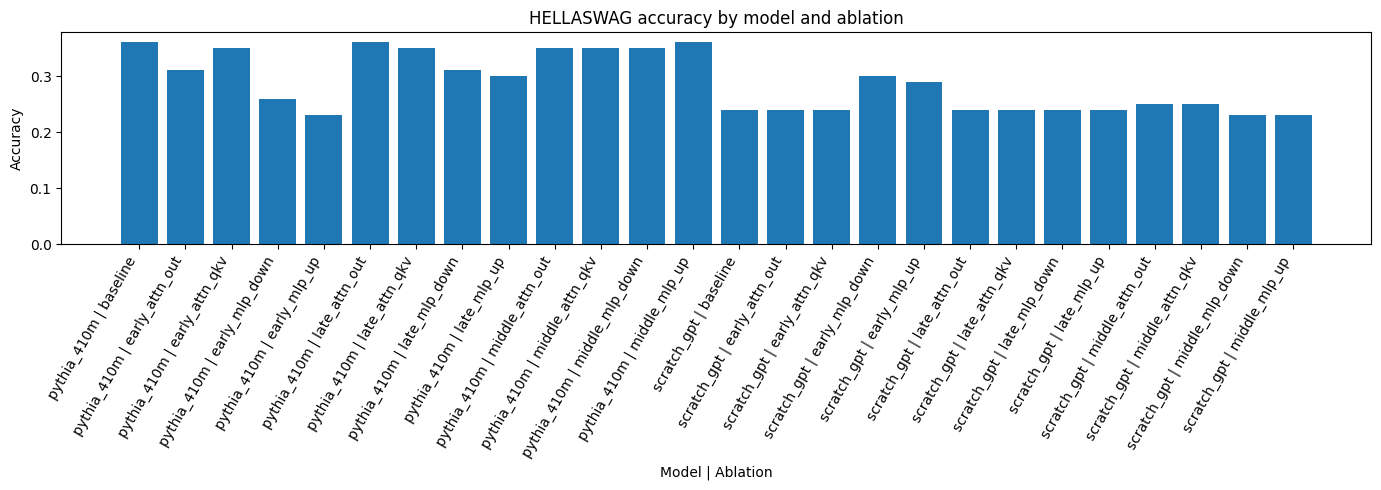

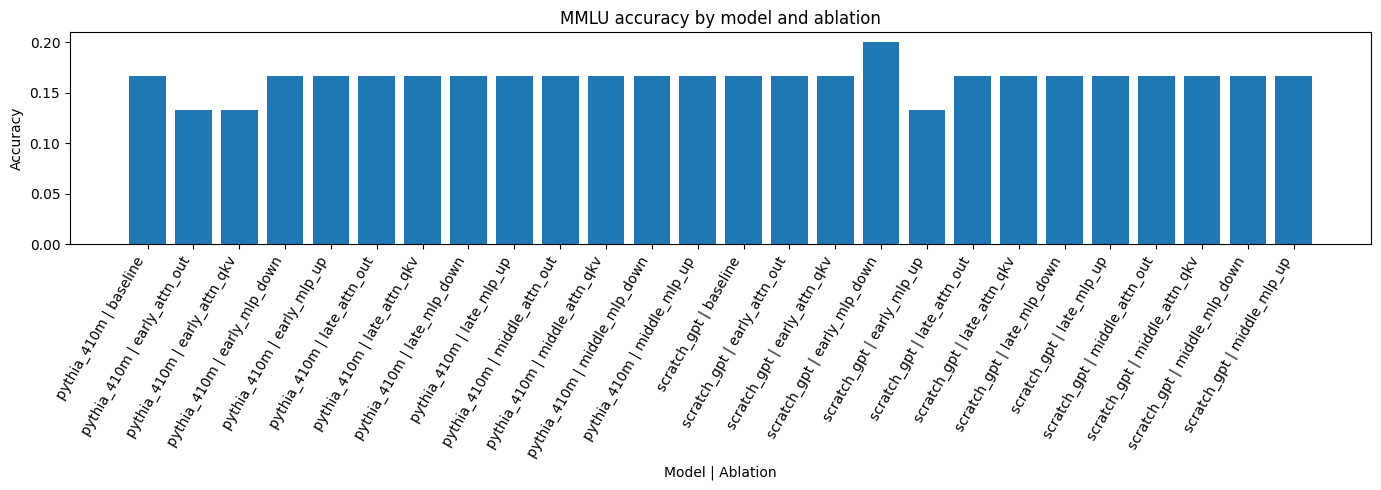

In [23]:
# Visualization: absolute accuracy by model and  ablation
for benchmark in sorted(combined_results["benchmark"].unique()):
    subset = combined_results[combined_results["benchmark"] == benchmark].copy()
    subset["label"] = subset["model_family"] + " | " + subset["ablation"]
    subset = subset.sort_values(["model_family", "ablation"])

    plt.figure(figsize=(14, 5))
    plt.bar(subset["label"], subset["accuracy"])
    plt.title(f"{benchmark.upper()} accuracy by model and ablation")
    plt.ylabel("Accuracy")
    plt.xlabel("Model | Ablation")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


model_family,pythia_410m,scratch_gpt
ablation,,
baseline,0.00,0.00
early_attn_out,-0.05,0.00
early_attn_qkv,-0.01,0.00
early_mlp_down,-0.10,0.06
early_mlp_up,-0.13,0.05
late_attn_out,0.00,0.00
late_attn_qkv,-0.01,0.00
late_mlp_down,-0.05,0.00
late_mlp_up,-0.06,0.00


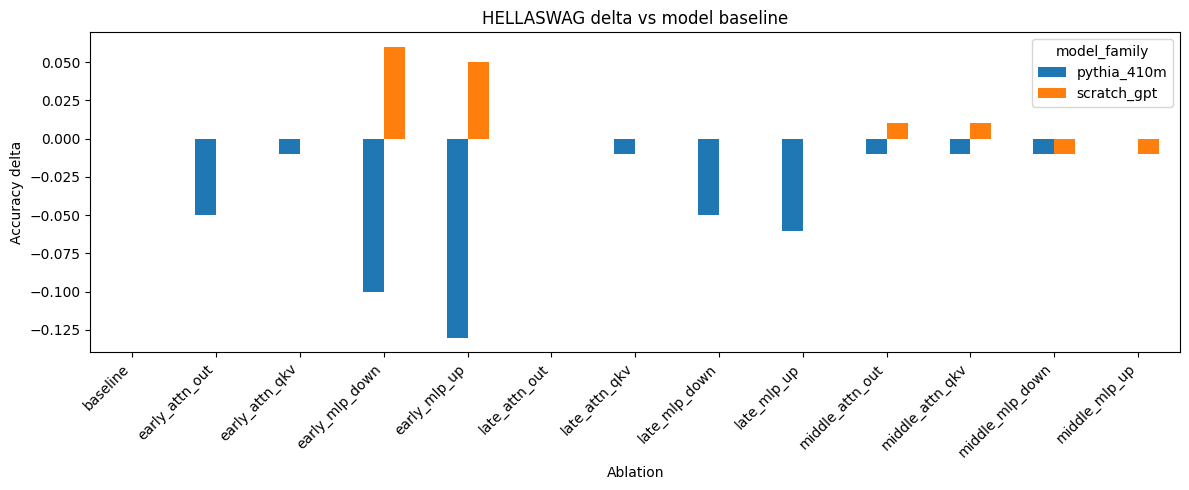

model_family,pythia_410m,scratch_gpt
ablation,,
baseline,0.000000,0.000000
early_attn_out,-0.033333,0.000000
early_attn_qkv,-0.033333,0.000000
early_mlp_down,0.000000,0.033333
early_mlp_up,0.000000,-0.033333
late_attn_out,0.000000,0.000000
late_attn_qkv,0.000000,0.000000
late_mlp_down,0.000000,0.000000
late_mlp_up,0.000000,0.000000


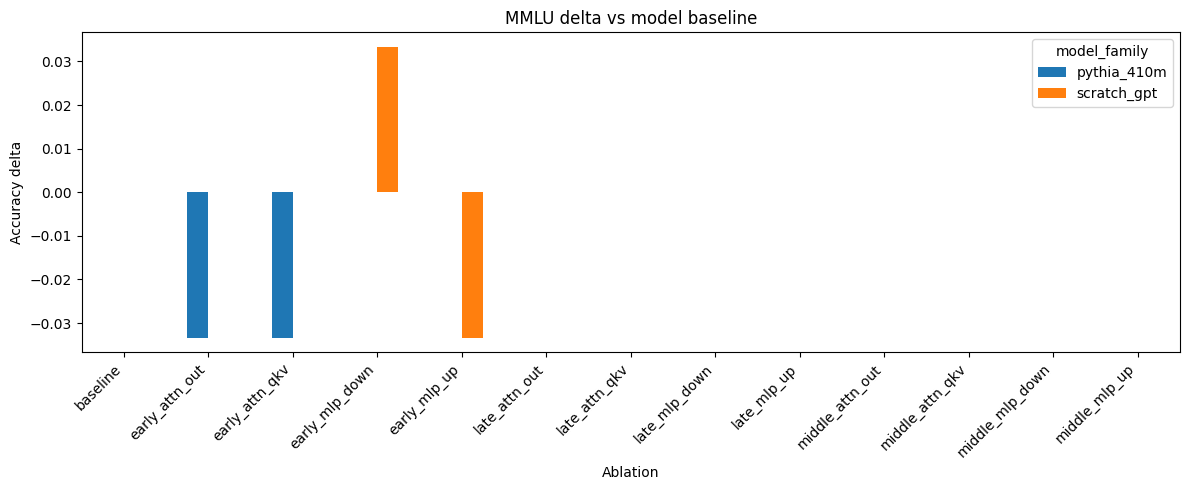

In [24]:
# Visualization: delta vs each model's own baseline
for benchmark in sorted(combined_results["benchmark"].unique()):
    subset = combined_results[combined_results["benchmark"] == benchmark].copy()
    pivot = subset.pivot(index="ablation", columns="model_family", values="delta_vs_model_baseline").sort_index()

    display(pivot)

    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title(f"{benchmark.upper()} delta vs model baseline")
    ax.set_ylabel("Accuracy delta")
    ax.set_xlabel("Ablation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



  REPEATED ABLATION  –  run 1/3  (seed=42)
 gpt initialisation done - 354,823,168 number of parameters354.8M)

=== scratch_gpt: baseline ===


HellaSwag (100):   0%|          | 0/100 [00:00<?, ?it/s]

MMLU/high_school_biology (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/high_school_mathematics (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/computer_security (10):   0%|          | 0/10 [00:00<?, ?it/s]

...

MMLU/high_school_biology (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/high_school_mathematics (10):   0%|          | 0/10 [00:00<?, ?it/s]

MMLU/computer_security (10):   0%|          | 0/10 [00:00<?, ?it/s]


  AVERAGED RESULTS  (mean ± std over 3 runs)


,model_family,benchmark,ablation,accuracy,delta,n
0,pythia_410m,hellaswag,baseline,0.360 ± 0.000,+0.000 ± 0.000,100
2,pythia_410m,hellaswag,early_attn_out,0.310 ± 0.000,-0.050 ± 0.000,100
4,pythia_410m,hellaswag,early_attn_qkv,0.350 ± 0.000,-0.010 ± 0.000,100
6,pythia_410m,hellaswag,early_mlp_down,0.260 ± 0.000,-0.100 ± 0.000,100
8,pythia_410m,hellaswag,early_mlp_up,0.230 ± 0.000,-0.130 ± 0.000,100
10,pythia_410m,hellaswag,late_attn_out,0.360 ± 0.000,+0.000 ± 0.000,100
12,pythia_410m,hellaswag,late_attn_qkv,0.350 ± 0.000,-0.010 ± 0.000,100
14,pythia_410m,hellaswag,late_mlp_down,0.310 ± 0.000,-0.050 ± 0.000,100
16,pythia_410m,hellaswag,late_mlp_up,0.300 ± 0.000,-0.060 ± 0.000,100
18,pythia_410m,hellaswag,middle_attn_out,0.350 ± 0.000,-0.010 ± 0.000,100


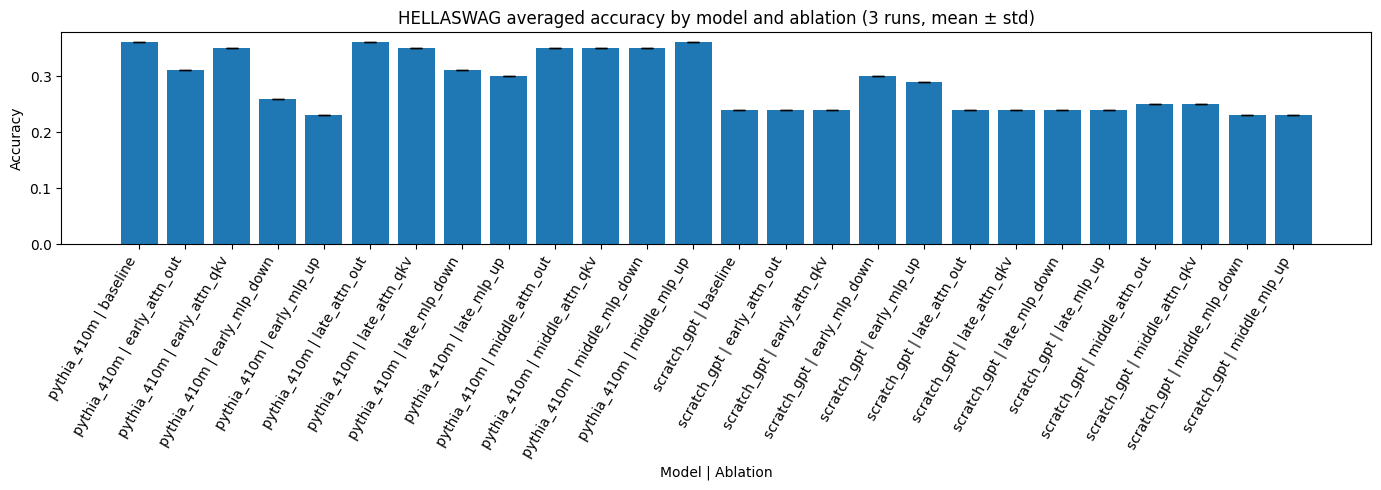

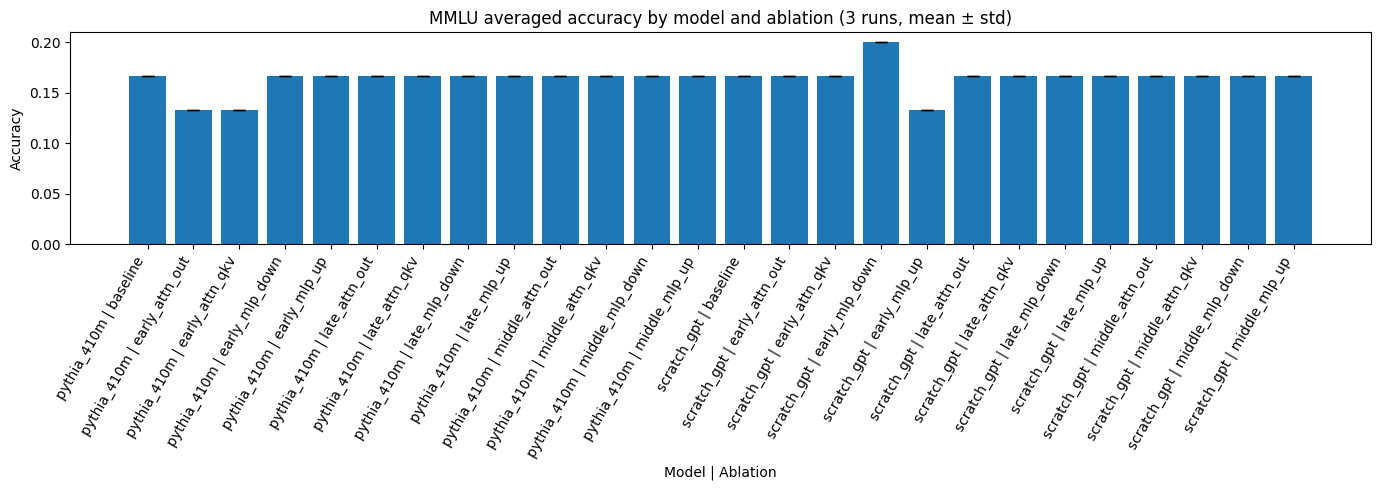

model_family,pythia_410m,scratch_gpt
ablation,,
baseline,0.00,0.00
early_attn_out,-0.05,0.00
early_attn_qkv,-0.01,0.00
early_mlp_down,-0.10,0.06
early_mlp_up,-0.13,0.05
late_attn_out,0.00,0.00
late_attn_qkv,-0.01,0.00
late_mlp_down,-0.05,0.00
late_mlp_up,-0.06,0.00


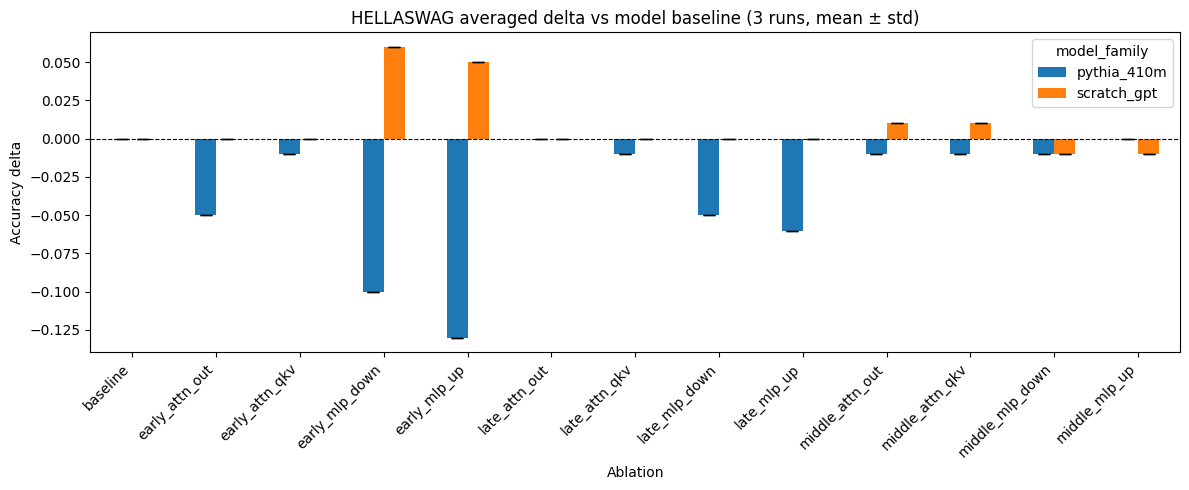

model_family,pythia_410m,scratch_gpt
ablation,,
baseline,0.000000,0.000000
early_attn_out,-0.033333,0.000000
early_attn_qkv,-0.033333,0.000000
early_mlp_down,0.000000,0.033333
early_mlp_up,0.000000,-0.033333
late_attn_out,0.000000,0.000000
late_attn_qkv,0.000000,0.000000
late_mlp_down,0.000000,0.000000
late_mlp_up,0.000000,0.000000


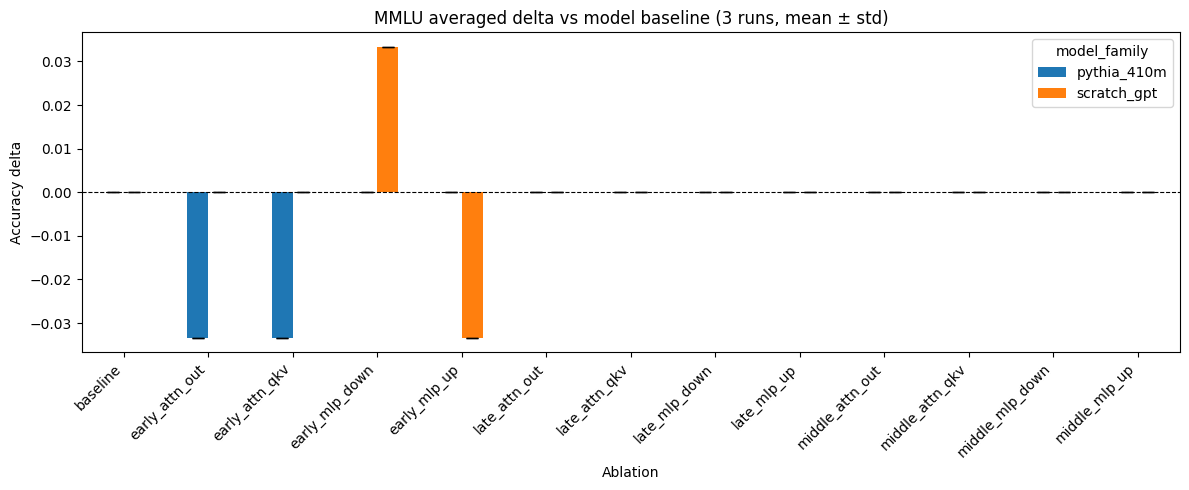


Done. Averaged results saved to: /content/drive/MyDrive/gpt_comp432_project_40068843/ablation_results


In [25]:
#REPEATED ABLATION: runs the full suite 3 times and averages the results
# this is what is in the report, its based on the above one - run results

N_RUNS = 3
RUN_SEEDS = [42, 7, 2025]

all_run_frames = []

for run_idx, seed in enumerate(RUN_SEEDS):
    print(f"\n{'='*60}")
    print(f"  REPEATED ABLATION  –  run {run_idx + 1}/{N_RUNS}  (seed={seed})")
    print(f"{'='*60}")

    # scratch
    scratch_model, scratch_tokenizer = load_scratch_model(SCRATCH_CKPT_DIR)
    scratch_plan = build_scratch_ablation_plan(scratch_model)
    scratch_results, _ = run_ablation_suite(
        model_name="scratch_gpt",
        model=scratch_model,
        tokenizer=scratch_tokenizer,
        ablation_plan=scratch_plan,
        hellaswag_n=HELLASWAG_N,
        mmlu_subjects=MMLU_SUBJECTS,
        mmlu_n_per_subject=MMLU_N_PER_SUBJECT,
    )
    cleanup_model(scratch_model)
    del scratch_tokenizer

    # pythia
    pythia_model, pythia_tokenizer = load_pythia_model(PYTHIA_MODEL_ID)
    pythia_plan = build_pythia_ablation_plan(pythia_model)
    pythia_results, _ = run_ablation_suite(
        model_name="pythia_410m",
        model=pythia_model,
        tokenizer=pythia_tokenizer,
        ablation_plan=pythia_plan,
        hellaswag_n=HELLASWAG_N,
        mmlu_subjects=MMLU_SUBJECTS,
        mmlu_n_per_subject=MMLU_N_PER_SUBJECT,
    )
    cleanup_model(pythia_model)
    del pythia_tokenizer

    run_df = pd.concat([scratch_results, pythia_results], ignore_index=True)
    run_df["run"] = run_idx + 1
    all_run_frames.append(run_df)


# aggregate

all_runs_df = pd.concat(all_run_frames, ignore_index=True)

GROUP_KEYS = ["model_family", "ablation", "benchmark"]

avg_results = (
    all_runs_df
    .groupby(GROUP_KEYS, as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        delta_mean=("delta_vs_model_baseline", "mean"),
        delta_std=("delta_vs_model_baseline", "std"),
        n=("n", "first"),
    )
)

all_runs_df.to_csv(os.path.join(RESULTS_DIR, "all_runs_ablation_results.csv"), index=False)
avg_results.to_csv(os.path.join(RESULTS_DIR, "averaged_ablation_results.csv"), index=False)


#  TABLE

print("\n" + "="*60)
print("  AVERAGED RESULTS  (mean ± std over 3 runs)")
print("="*60)

display_df = avg_results.copy()
display_df["accuracy"] = (
    display_df["accuracy_mean"].map("{:.3f}".format)
    + " ± "
    + display_df["accuracy_std"].map("{:.3f}".format)
)
display_df["delta"] = (
    display_df["delta_mean"].map("{:+.3f}".format)
    + " ± "
    + display_df["delta_std"].map("{:.3f}".format)
)
display(
    display_df[["model_family", "benchmark", "ablation", "accuracy", "delta", "n"]]
    .sort_values(["benchmark", "model_family", "ablation"])
)


# VISUALISATION 1: avg absolute accuracy

for benchmark in sorted(avg_results["benchmark"].unique()):
    subset = avg_results[avg_results["benchmark"] == benchmark].copy()
    subset["label"] = subset["model_family"] + " | " + subset["ablation"]
    subset = subset.sort_values(["model_family", "ablation"])

    plt.figure(figsize=(14, 5))
    plt.bar(subset["label"], subset["accuracy_mean"], yerr=subset["accuracy_std"], capsize=4)
    plt.title(f"{benchmark.upper()} averaged accuracy by model and ablation (3 runs, mean ± std)")
    plt.ylabel("Accuracy")
    plt.xlabel("Model | Ablation")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


# VISUALISATION 2: avg delta vs baseline

for benchmark in sorted(avg_results["benchmark"].unique()):
    subset = avg_results[avg_results["benchmark"] == benchmark].copy()

    pivot_mean = subset.pivot(
        index="ablation", columns="model_family", values="delta_mean"
    ).sort_index()
    pivot_std = subset.pivot(
        index="ablation", columns="model_family", values="delta_std"
    ).sort_index()

    display(pivot_mean)

    ax = pivot_mean.plot(kind="bar", figsize=(12, 5),
                         yerr=pivot_std, capsize=4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{benchmark.upper()} averaged delta vs model baseline (3 runs, mean ± std)")
    ax.set_ylabel("Accuracy delta")
    ax.set_xlabel("Ablation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nDone. Averaged results saved to:", RESULTS_DIR)